# Introduction to causal inference
**DS-UA 201 · Fall 2026**  
**Center for Data Science, New York University**

**TA: Xiang Gao**

September 11, 2026

[Open in Colab](https://colab.research.google.com/github/xgao0o/DS-UA_201-Causal-Inference-Fall-2026/blob/main/labs/1-Introduction.ipynb) (available after publication to the repository).

All grades below are simulated for teaching. The assumed attendance effect is not an empirical finding.

## Goals for today
- Review the tools for running Python code.
- Distinguish descriptive questions from causal questions.
- Introduce the all-causes model and the fundamental problem of causal inference.
- Define and calculate a causal effect in a simulation, then estimate it using observed outcomes.
- Review probability mass, density, cumulative probability, expectations, and variance.


## Setup and tools for running code
Open this notebook in Jupyter or upload it to Google Colab. Run each cell with **Shift+Enter**, working from top to bottom. Restart the kernel and run all cells to reproduce the saved results.

For local setup, see the [course README](../README.md). We use NumPy, pandas, and Matplotlib; the examples require no external data downloads. A fixed random seed makes the simulated results reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf
from IPython.display import display

plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## The effect of class attendance on grades
A professor wants to understand whether attending class regularly improves grades. Describing the grades students received and learning the effect of attendance are different tasks.

- **Descriptive:** What is the average grade in the course?
- **Descriptive association:** Do regular attendees have higher grades than irregular attendees?
- **Causal:** How would grades differ if the same students attended regularly rather than irregularly?

Our target population is the students represented by this example, and the outcome is their grade at the end of the course.

### Notation
The lecture's all-causes model is

$$Y_i(s,u),$$

the grade for student $i$ under attendance state $s$, with all other relevant factors held at $u$.

- $s=1$: regular attendance; $s=0$: irregular attendance.
- $u$: other influences, such as prior knowledge, study habits, and motivation.
- $S_i$: the attendance state the student actually experiences.

For brevity, write $Y_i(1)=Y_i(1,U_i)$ and $Y_i(0)=Y_i(0,U_i)$ for the two **potential outcomes**. The observed grade is $Y_i=Y_i(S_i)$, assuming the observed outcome agrees with the potential outcome for the actual attendance state.

### Descriptive analysis
First, generate a simple dataset of grades and attendance indicators. At this stage, the two variables are generated independently: **we have not built an attendance effect into these grades**. This first dataset is just for practicing descriptive analysis.

Grades follow a normal distribution with mean 75 and standard deviation 12. A normal distribution is unbounded, so these illustrative scores may fall outside 0–100. We do not clip them in this example.


In [2]:
rng = np.random.default_rng(42)
students = 1000
mean_grade = 75
std_grade = 12

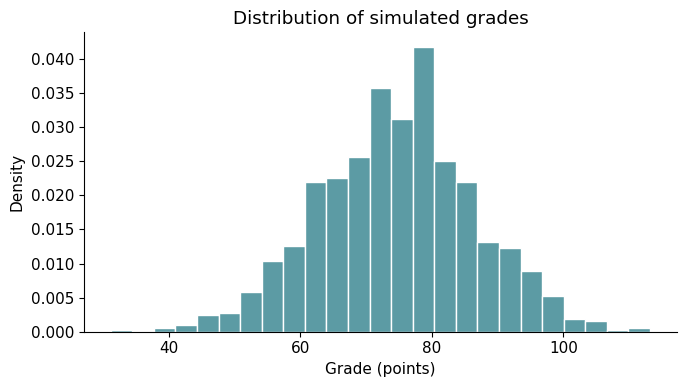

In [3]:
baseline_grades = rng.normal(mean_grade, std_grade, students)
attendance = rng.binomial(1, 0.6, students)
grades = pd.DataFrame({"Grade": baseline_grades, "Attendance": attendance})

fig, ax = plt.subplots()
ax.hist(grades["Grade"], bins=25, density=True, color="#5c9ba4", edgecolor="white")
ax.set(title="Distribution of simulated grades", xlabel="Grade (points)", ylabel="Density")
fig.tight_layout()
plt.show()

**What is the average grade in this course?**

We summarize the observed grades using the sample mean:

$$\bar{Y}=\frac{1}{N}\sum_{i=1}^{N}Y_i.$$

Here, $N$ is the number of students. The sample mean is a statistic computed from our data; $\mathbb{E}[Y]$ is the population expectation that it estimates. We are averaging over students with their actual attendance states, not setting everyone to the same state.

In [4]:
grades.head(5)

,Grade,Attendance
0,78.656605,0
1,62.520191,1
2,84.005414,1
3,86.286777,1
4,51.587578,1


In [5]:
print(f"Average grade in this simulated course: {grades['Grade'].mean():.2f} points.")

Average grade in this simulated course: 74.65 points.


**Does the overall average tell us the effect of attendance?**

No. It describes the grades in this dataset without comparing interventions. In an actual study, we observe each student under only one attendance state, not both. The unobserved alternative is the **counterfactual**. This is the fundamental problem of causal inference.

Even comparing regular attendees with irregular attendees is not automatically causal: their prior knowledge, motivation, or other characteristics may differ.

### From descriptive to causal analysis in a simulated world
We now give the same baseline grades a causal interpretation and construct a **new simulated scenario**:

$$Y_i(0)=\text{baseline grade}_i,\qquad Y_i(1)=\text{baseline grade}_i+10.$$

Every student has a 10-point individual effect in this model. Other influences still affect baseline grades. Treatment being the only cause of the outcome is **not** an assumption we need.

The population **average treatment effect (ATE)** is

$$\mathrm{ATE}=\mathbb{E}[Y(1)-Y(0)].$$

Because the effect is constant, this equals 10. In our finite simulated population we can also compute

$$\mathrm{ATE}_N=\frac{1}{N}\sum_{i=1}^{N}\bigl(Y_i(1)-Y_i(0)\bigr)=10.$$

We can see both potential outcomes because we are constructing the simulation. In real data, we would not have this complete table. Define both outcomes **before** using attendance to select which one is observed.

In [6]:
attend_effect = 10
# Potential outcomes for EVERY student, regardless of actual attendance.
grades_nattend = baseline_grades.copy()
grades_attend = baseline_grades + attend_effect

# Idealized random assignment, independent of the potential outcomes.
attendance = rng.binomial(1, 0.5, students)
grades_observed = np.where(attendance == 1, grades_attend, grades_nattend)

attend = pd.DataFrame({
    "Student_ID": np.arange(1, students + 1),
    "Attendance": attendance,
    "Grade_With_Attendance": grades_attend,
    "Grade_Without_Attendance": grades_nattend,
    "Observed_Grade": grades_observed
})

In [7]:
attend.head(5)

,Student_ID,Attendance,Grade_With_Attendance,Grade_Without_Attendance,Observed_Grade
0,1,1,88.656605,78.656605,88.656605
1,2,1,72.520191,62.520191,72.520191
2,3,0,94.005414,84.005414,84.005414
3,4,1,96.286777,86.286777,96.286777
4,5,1,61.587578,51.587578,61.587578


In [8]:
attend[["Grade_With_Attendance", "Grade_Without_Attendance", "Observed_Grade"]].describe()

,Grade_With_Attendance,Grade_Without_Attendance,Observed_Grade
count,1000.000000,1000.000000,1000.000000
mean,84.653301,74.653301,79.643301
std,11.870605,11.870605,12.882807
min,41.219046,31.219046,31.219046
25%,76.644245,66.644245,70.948052
50%,85.074134,75.074134,79.732568
75%,92.078641,82.078641,88.653452
max,123.146244,113.146244,119.860806


In [9]:
# Compare both potential outcomes across the SAME students.
avg_reg = attend["Grade_With_Attendance"].mean()
avg_irr = attend["Grade_Without_Attendance"].mean()
ate = (attend["Grade_With_Attendance"] - attend["Grade_Without_Attendance"]).mean()

print(f"Average grade if everyone attended regularly: {avg_reg:.2f}")
print(f"Average grade if everyone attended irregularly: {avg_irr:.2f}")
print(f"True ATE in this simulation: {ate:.2f} grade points.")

Average grade if everyone attended regularly: 84.65
Average grade if everyone attended irregularly: 74.65
True ATE in this simulation: 10.00 grade points.


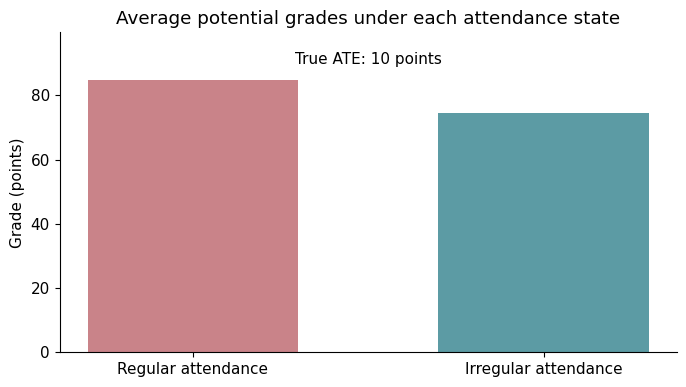

In [10]:
fig, ax = plt.subplots()
ax.bar(["Regular attendance", "Irregular attendance"], [avg_reg, avg_irr],
       color=["#c98389", "#5c9ba4"], width=0.6)
ax.set(title="Average potential grades under each attendance state",
       ylabel="Grade (points)", ylim=(0, max(avg_reg, avg_irr) + 15))
ax.text(0.5, max(avg_reg, avg_irr) + 5, f"True ATE: {ate:.0f} points", ha="center")
fig.tight_layout()
plt.show()

### Identification and estimation with observed outcomes
The lecture separates three steps: **define the parameter → identify it → estimate it**.

We have defined the ATE. To identify it using an observed difference in means, suppose attendance is randomized independently of both potential outcomes, $S\perp(Y(0),Y(1))$. Also assume that either state is possible for each student, attendance is well-defined, and a student's grade does not depend on other students' attendance. In this idealized example, students experience their assigned attendance state.

Then consistency and independence give

$$\mathrm{ATE}=\mathbb{E}[Y\mid S=1]-\mathbb{E}[Y\mid S=0].$$

We estimate these population conditional means with sample means:

$$\widehat{\tau}=\bar{Y}_{S=1}-\bar{Y}_{S=0}.$$

The following code uses **only observed grades and attendance**. The resulting estimate need not equal 10 exactly: the two randomly formed groups can have different average baseline grades in this particular sample.

In [ ]:
observed = attend[["Attendance", "Observed_Grade"]].copy()
group_means = observed.groupby("Attendance")["Observed_Grade"].mean()
estimated_ate = group_means.loc[1] - group_means.loc[0]

display(group_means.rename(index={0: "Irregular attendance", 1: "Regular attendance"}).to_frame())
print(f"Difference in observed group means: {estimated_ate:.2f} grade points")
print(f"True ATE from the complete simulation: {ate:.2f} grade points")

,Observed_Grade
Attendance,
Irregular attendance,74.650258
Regular attendance,84.656357


Difference in observed group means: 10.01 grade points
True ATE from the complete simulation: 10.00 grade points


### Quick check
Why is the true simulated ATE exactly 10, while the difference in observed group means may not be? Would a larger observational dataset automatically justify a causal interpretation?

<details><summary>Answer</summary>

The true ATE compares both potential outcomes for the same students, and each difference is 10. The observed comparison uses different students in the two groups, whose baseline grades can differ by chance. Without random assignment or another identification argument, differences in baseline characteristics can produce systematic bias. More observations do not automatically remove it.

</details>

## Probability
These ideas help distinguish a population parameter from the sample quantity used to estimate it.

### Probability mass and density functions
A **probability mass function (PMF)** gives point probabilities for a discrete random variable:

$$p_X(x)=P(X=x),\qquad \sum_x p_X(x)=1.$$

For a fair six-sided die, each integer from 1 through 6 has probability $1/6$.

A **probability density function (PDF)** describes a continuous random variable. Its area over an interval gives probability:

$$P(a<X\leq b)=\int_a^b f_X(x)\,dx,\qquad \int_{-\infty}^{\infty}f_X(x)\,dx=1.$$

A density value is not a point probability. For a continuous distribution, $P(X=x)=0$, and a density can exceed 1.

P(X = 3): 0.167
Sum of die probabilities: 1.000


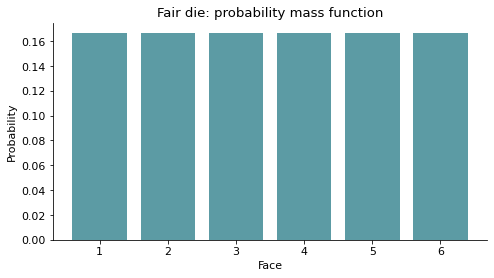

In [ ]:
def pmf_die(x):
    """Point probability for one roll of a fair six-sided die."""
    return 1 / 6 if x in (1, 2, 3, 4, 5, 6) else 0.0


def pdf_gaussian(x, mu=0.0, sigma=1.0):
    """Normal density; sigma is a strictly positive standard deviation."""
    if sigma <= 0:
        raise ValueError("sigma must be positive")
    x = np.asarray(x)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

faces = np.arange(1, 7)
probabilities = np.array([pmf_die(face) for face in faces])
print(f"P(X = 3): {pmf_die(3):.3f}")
print(f"Sum of die probabilities: {probabilities.sum():.3f}")
fig, ax = plt.subplots()
ax.bar(faces, probabilities, color="#5c9ba4")
ax.set(title="Fair die: probability mass function", xlabel="Face", ylabel="Probability", xticks=faces)
fig.tight_layout()
plt.show()

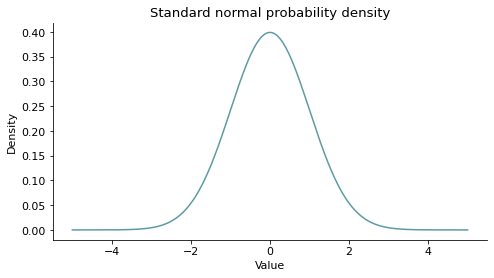

In [ ]:
x = np.linspace(-5, 5, 1000)
y = pdf_gaussian(x)
fig, ax = plt.subplots()
ax.plot(x, y, color="#5c9ba4")
ax.set(title="Standard normal probability density", xlabel="Value", ylabel="Density")
fig.tight_layout()
plt.show()

### Cumulative distribution function
The **CDF** is $F_X(x)=P(X\leq x)$. For a continuous random variable,

$$F_X(x)=\int_{-\infty}^{x} f_X(t)\,dt.$$

Simply summing PDF heights does not approximate a probability: the grid spacing matters. Below, the cumulative trapezoidal rule adds the area of each small interval, using its width $\Delta x$ and average endpoint density.

Our grid starts at −5, so this calculation initially approximates the integral from −5 to $x$, not from $-\infty$. The omitted standard normal tail is tiny. Normalizing the cumulative values to end at 1 would instead describe a distribution truncated to the grid interval.

Approximate probability between -5 and 5: 0.99999943
Maximum difference from full normal CDF: 2.31e-06


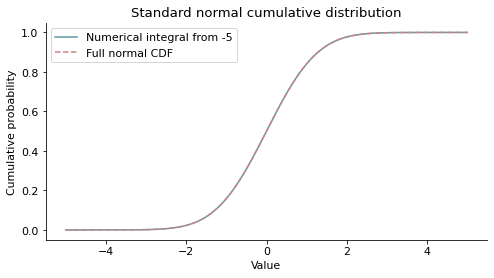

In [ ]:
dx = np.diff(x)
interval_areas = 0.5 * (y[:-1] + y[1:]) * dx
y_cdf = np.concatenate(([0.0], np.cumsum(interval_areas)))

# Standard-library reference for the full standard normal CDF.
normal_cdf = np.array([0.5 * (1 + erf(value / np.sqrt(2))) for value in x])
print(f"Approximate probability between -5 and 5: {y_cdf[-1]:.8f}")
print(f"Maximum difference from full normal CDF: {np.max(np.abs(y_cdf - normal_cdf)):.2e}")
fig, ax = plt.subplots()
ax.plot(x, y_cdf, label="Numerical integral from -5", color="#5c9ba4")
ax.plot(x, normal_cdf, linestyle="--", label="Full normal CDF", color="#c98389")
ax.set(title="Standard normal cumulative distribution", xlabel="Value", ylabel="Cumulative probability")
ax.legend()
fig.tight_layout()
plt.show()

### Functions of random variables
We often want the expectation of a transformed variable, such as $X^2$. When the expectation exists:

$$\mathbb{E}[g(X)]=\sum_x g(x)p_X(x) \quad\text{(discrete)},$$

$$\mathbb{E}[g(X)]=\int_{-\infty}^{\infty}g(x)f_X(x)\,dx \quad\text{(continuous)}.$$

For a fair die, calculate $\mathbb{E}[X]$ and $\mathbb{E}[X^2]$ by weighting each value (or squared value) by its probability. Notice that $\mathbb{E}[X^2]$ and $\mathbb{E}[X]^2$ are different quantities.

In [ ]:
expected_x = np.sum(faces * probabilities)
expected_x2 = np.sum(faces**2 * probabilities)
print(f"E[X] = {expected_x:.4f}")
print(f"E[X²] = {expected_x2:.4f}")
print(f"E[X]² = {expected_x**2:.4f}")

E[X] = 3.5000
E[X²] = 15.1667
E[X]² = 12.2500


### Variance
Variance measures dispersion around the expectation. Assuming a finite second moment and writing $\mu=\mathbb{E}[X]$,

$$\begin{aligned}
\operatorname{Var}(X)
&=\mathbb{E}[(X-\mu)^2]\\
&=\mathbb{E}[X^2]-2\mu\mathbb{E}[X]+\mu^2\\
&=\mathbb{E}[X^2]-\mathbb{E}[X]^2.
\end{aligned}$$

Here $\mu$ is a constant, so it can be taken outside the expectation. Variance is in squared units; the standard deviation is its square root.

In [ ]:
variance_direct = np.sum((faces - expected_x)**2 * probabilities)
variance_identity = expected_x2 - expected_x**2
print(f"Variance from squared deviations: {variance_direct:.4f}")
print(f"Variance from E[X²] - E[X]²: {variance_identity:.4f}")
print(f"Standard deviation: {np.sqrt(variance_direct):.4f}")

Variance from squared deviations: 2.9167
Variance from E[X²] - E[X]²: 2.9167
Standard deviation: 1.7078
